# 지도학습 Project

- 펭귄의 신체 측정값과 서식 정보를 이용하여 펭귄의 종, 성별, 몸무게를 예측하는 지도학습 프로젝트

- 사용 데이터셋
    - 데이터셋 명 : Palmer Penguins Dataset
    - 주요 컬럼
        - species: 펭귄 종
        - island: 서식 섬
        - bill_length_mm: 부리 길이
        - bill_depth_mm: 부리 깊이
        - flipper_length_mm: 날개 길이
        - body_mass_g: 몸무게
        - sex: 성별
        - year: 관측 연도

In [1]:
import pandas as pd
import numpy as np
 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder # 원 - 핫 인코딩
le = LabelEncoder()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split 

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [2]:
df = sns.load_dataset("penguins")

In [3]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


결측치 확인

In [5]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

결측치 제거 결정

In [6]:
df.dropna(inplace = True)

결측치 재확인

In [7]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [8]:
numeric_cols = df.select_dtypes(include=['number']).columns
species_avg = df.groupby("species")[numeric_cols].mean()
print("종별 숫자형 변수 평균 : \n {}".format(species_avg))

종별 숫자형 변수 평균 : 
            bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.823973      18.347260         190.102740  3706.164384
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.568067      14.996639         217.235294  5092.436975


종별 산점도 

상관도 확인 - Correlation Matrix

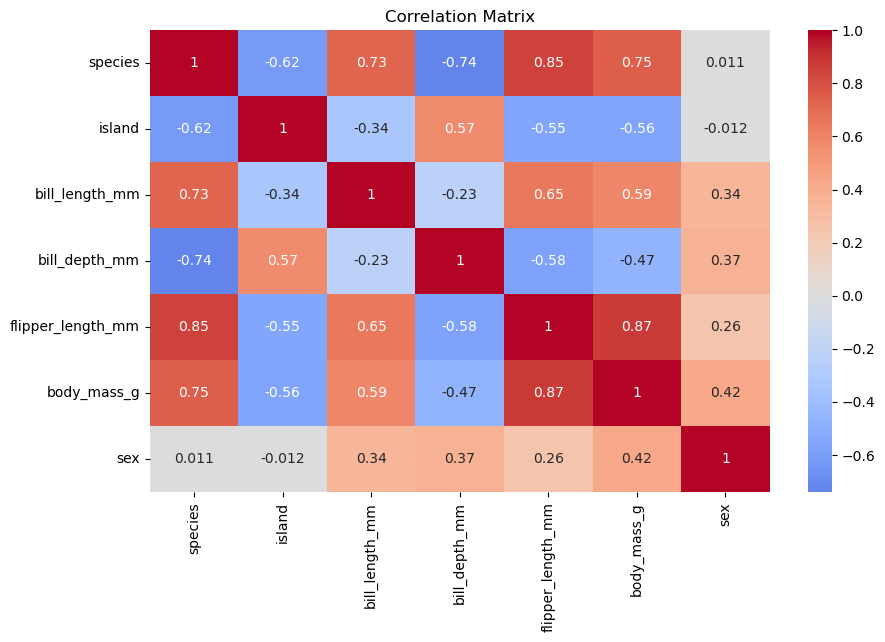

In [9]:
# TODO 3-5: 상관계수 행렬과 히트맵

import numpy as np
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

타겟 확인

In [10]:
df['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [11]:
df['targets'] = df['species'].map({
    'Adelie' : 0,
    'Chinstrap' : 1,
    'Gentoo' : 2})

타겟 정의

In [12]:
pg_target_names = df['species'].unique()
pg_target_names

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [13]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,targets
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0


범주형 데이터 원-핫 인코딩

In [14]:
df['island_label'] = le.fit_transform(df['island'])
df['sex_label'] = le.fit_transform(df['sex']) 
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,targets,island_label,sex_label
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0,2,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0,2,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0,2,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0,2,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0,2,1


범주형 데이터 및 타겟 제외 변수 특정

In [15]:
X , y = df.drop(['species','island','sex','targets'],axis=1) , df['targets'] # axis 0 행 1 열 

In [16]:
X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_label,sex_label
0,39.1,18.7,181.0,3750.0,2,1
1,39.5,17.4,186.0,3800.0,2,0
2,40.3,18.0,195.0,3250.0,2,0
4,36.7,19.3,193.0,3450.0,2,0
5,39.3,20.6,190.0,3650.0,2,1


훈련 데이터 스플릿 

In [17]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y,
    test_size = 0.2 , # 8 : 2  
    random_state = 42 , # 실행할 때마다 같은 결과가 나오도록 기준 유지 
    stratify = y
)  

데이터 스케일링

In [18]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1. Logistic Regression

In [19]:
# Logistic Regression 모델 
from sklearn.linear_model import LogisticRegression

## Logistic Regression 모델 생성

In [20]:
Logistic_model = LogisticRegression(
    max_iter = 100 , # 반복 수 
    random_state = 42)

Logistic Regression 모델 학습

In [21]:
Logistic_model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Logistic Regression 모델 예측 

In [22]:
y_pred_logistic = Logistic_model.predict(X_test_scaled)
y_pred_logistic

array([2, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 0, 0, 1, 1, 0, 1, 0, 1, 2, 1, 2,
       0, 2, 2, 0, 0, 0, 2, 1, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2, 2,
       1, 0, 2, 1, 2, 1, 2, 0, 1, 0, 2, 0, 0, 1, 0, 2, 0, 2, 2, 0, 2, 0,
       0])

## 2. Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier , plot_tree 

Decision Tree 모델 생성

In [24]:
Decision_model = DecisionTreeClassifier(
    max_depth = 3 , # tree 의 최대 깊이 제한 
    random_state = 42)

In [25]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y,
    test_size = 0.2 , # 8 : 2  
    random_state = 42 , 
    stratify = y
)  

Decision Tree 모델 학습

In [26]:
Decision_model.fit(X_train_scaled,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Decision Tree 모델 예측

In [27]:
y_pred_dt = Decision_model.predict(X_test_scaled)
y_pred_dt

array([2, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 0, 0, 1, 0, 0, 1, 0, 1, 2, 1, 2,
       0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 1, 2,
       1, 0, 2, 1, 2, 1, 2, 0, 1, 0, 2, 0, 0, 1, 0, 2, 0, 2, 2, 0, 2, 0,
       0])

Decision Tree 시각화 분석

In [28]:
X.columns

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
       'island_label', 'sex_label'],
      dtype='object')

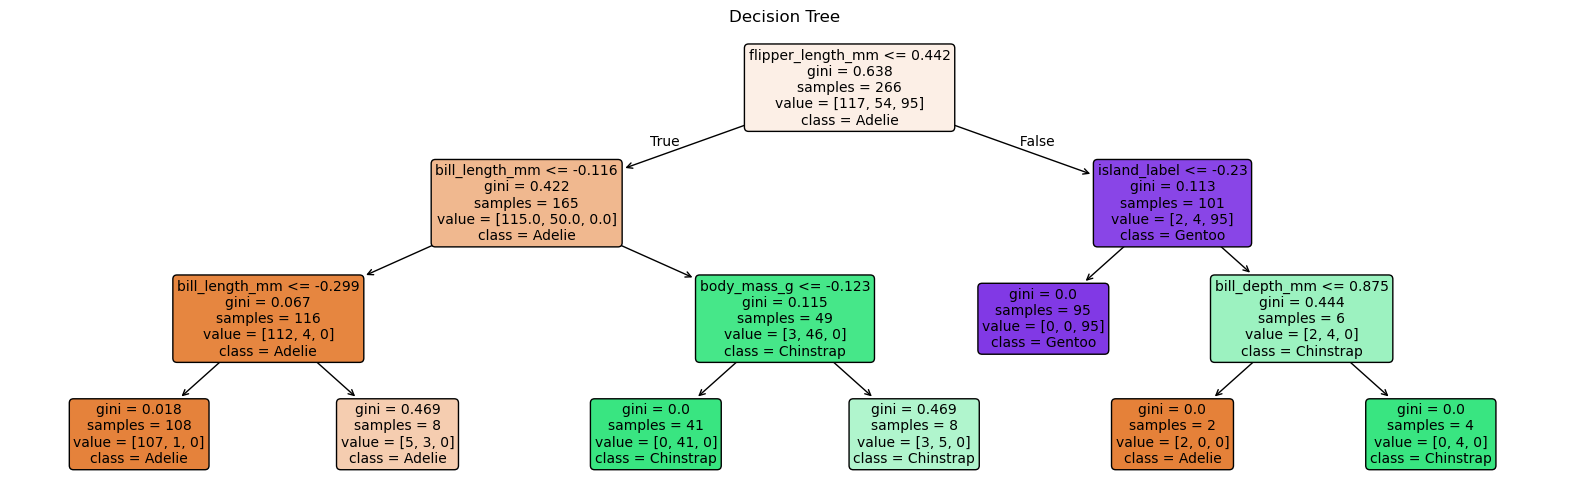

In [29]:
plt.figure(figsize=(20,6))

plot_tree(Decision_model ,
          feature_names = X.columns , # 가장 잘 분류되는 feature 로 모델이 잡아줌 
          class_names = pg_target_names,
          filled = True ,  # tree에 색 구분 , 완벽하게 분류될수록 색이 진하다 
          rounded = True, # Decision Tree 모서리 처리 
          fontsize = 10) # font 크기 설정 

plt.title("Decision Tree")
plt.show()  

Decision Tree 모델 Feature Importance 분석

In [30]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance' : Decision_model.feature_importances_}) 

# sklearn에서 모델 학습 이후 생기는 값 뒤에는 _ 처리하는 경향이 존재함.

importance = importance.sort_values(
    by = 'importance',
    ascending = True # 내림차순 
)

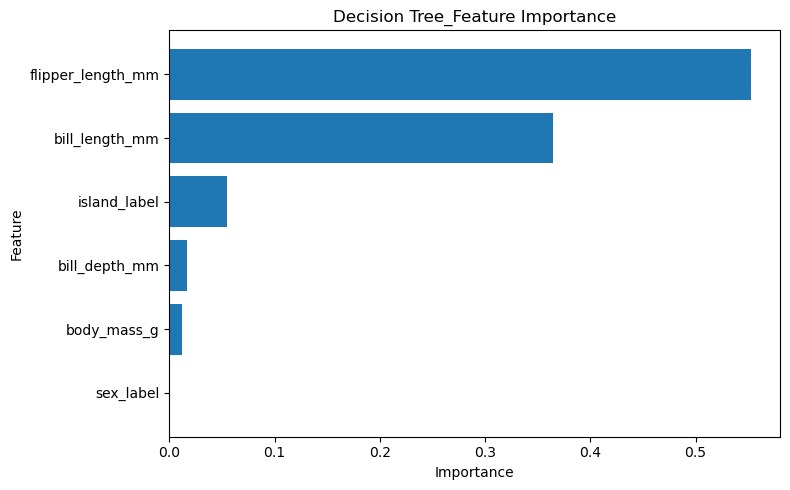

In [31]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['feature'],
    importance['importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Decision Tree_Feature Importance')

# plt.gca().invert_yaxis() # 현재의 그래프 Y축을 뒤집기
plt.tight_layout()
plt.show()

## 3. Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

Random Forest 모델 생성

In [33]:
RF_model = RandomForestClassifier(
    n_estimators=100, # Decision tree 100개 생성 
    max_depth=None, # 트리 최대 깊이 제한 X => Overfitting ( 과대적합 위험 증가 )
    # 하이퍼 파라미터 튜닝을 통하여 깊이 조정  
    random_state= 42 # 기준점 통일
)

Random Forest 모델 학습

In [34]:
RF_model.fit(X_train,y_train)

# 데이터 분포에 대한 영향력이 적음 
# 스케일링 데이터를 넣으니 모든 데이터가 통일되었음?
# 스케일링 하면 컬럼간 범위가 너무 적어져서 훈련 오류

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Random Forest 모델 예측

In [35]:
y_pred_rf = RF_model.predict(X_test)
y_pred_rf

array([2, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 0, 0, 1, 1, 0, 1, 0, 1, 2, 1, 2,
       0, 2, 2, 0, 0, 1, 2, 1, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2, 2,
       1, 0, 2, 1, 2, 1, 2, 0, 1, 0, 2, 0, 0, 1, 0, 2, 0, 2, 2, 0, 2, 0,
       0])

Random Forest Feature Importance 분석

In [36]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance' : RF_model.feature_importances_}) 

# sklearn에서 모델 학습 이후 생기는 값 뒤에는 _ 처리하는 경향이 존재함.

importance = importance.sort_values(
    by = 'importance',
    ascending = True # 내림차순 
)

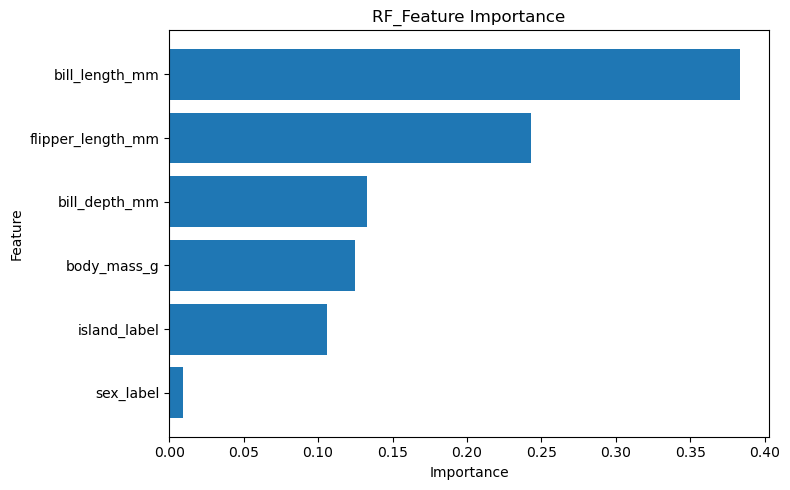

In [37]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['feature'],
    importance['importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('RF_Feature Importance')

# plt.gca().invert_yaxis() # 현재의 그래프 Y축을 뒤집기
plt.tight_layout()
plt.show()

### 4. Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression

Linear Regression 모델 생성

In [39]:
lr_model = LinearRegression()

In [40]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y,
    test_size = 0.2 , # 8 : 2  
    random_state = 42 , # 실행할 때마다 같은 결과가 나오도록 기준 유지 
    # stratify = y  회귀 모델에서는 사용 X
)  

Linear Regression 모델 학습

In [41]:
lr_model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Linear Regression 모델 예측

In [42]:
y_pred_lr = lr_model.predict(X_test_scaled)

Linear Regression 모델 검증 

In [43]:
from sklearn.metrics import mean_squared_error , r2_score

Linear Regression 모델 검증 : MSE

In [44]:
mse = mean_squared_error(y_test , y_pred_lr)
print(f"Linear Regression 모델의 MSE : {mse:.4f}") # 낮을수록 좋은 모델

Linear Regression 모델의 MSE : 0.8336


Linear Regression 모델 검증 : R^2

In [45]:
r2 = r2_score(y_test , y_pred_lr)
print(f"Linear Regression 모델의 R^2 : {r2:.4f}") # 높을수록 좋은 모델

Linear Regression 모델의 R^2 : -0.0529


<Axes: >

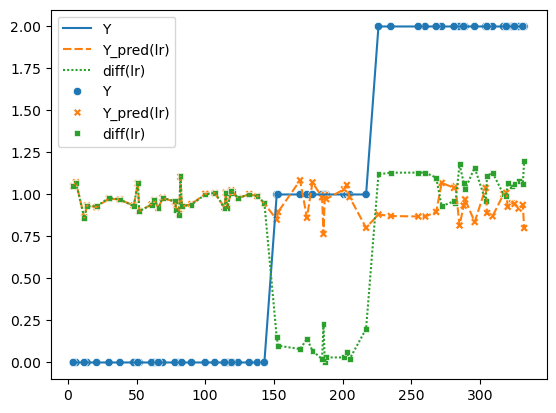

In [46]:
lr_df = pd.DataFrame(data = {'Y':y_test , 'Y_pred(lr)' : y_pred_lr , 
                             'diff(lr)' : np.round(np.abs(y_test - y_pred_lr),2)})
sns.lineplot(data = lr_df)
sns.scatterplot(data = lr_df)

## 모델 평가 
### 1. Accuracy

In [47]:
print("\n------------------------------------------------------\n")
accuracy_logistic = accuracy_score(y_test ,y_pred_logistic)
print("Logistic Regression 정확도 :" ,round(accuracy_logistic,4))
print("\n------------------------------------------------------\n")
accuracy_dt = accuracy_score(y_test ,y_pred_dt) 
print("Decision Tree 정확도 :" ,round(accuracy_dt,4))
print("\n------------------------------------------------------\n")
accuracy_rf = accuracy_score(y_test ,y_pred_rf)  
print("Random Forest 정확도 :" ,round(accuracy_rf,4))
print("\n------------------------------------------------------\n")


print("정확도가 가장 높은 모델은 Logistic Regression 모델이다.")


------------------------------------------------------

Logistic Regression 정확도 : 0.2985

------------------------------------------------------

Decision Tree 정확도 : 0.3284

------------------------------------------------------

Random Forest 정확도 : 0.2985

------------------------------------------------------

정확도가 가장 높은 모델은 Logistic Regression 모델이다.


### 2. Confusion_matrix

#### 1) Logistic Regression

In [48]:
cm = confusion_matrix(y_test , y_pred_logistic)
cm_df = pd.DataFrame(
    cm,
    index = ['실제 Adelie','실제 Chinstrap','실제 Gentoo'],
    columns = ['예측 Adelie','예측 Chinstrap','예측 Gentoo']
)
cm_df

,예측 Adelie,예측 Chinstrap,예측 Gentoo
실제 Adelie,14,8,9
실제 Chinstrap,4,0,9
실제 Gentoo,11,6,6


#### 2) Random Forest

In [49]:
cm = confusion_matrix(y_test , y_pred_rf)
cm_df = pd.DataFrame(
    cm,
    index = ['실제 Adelie','실제 Chinstrap','실제 Gentoo'],
    columns = ['예측 Adelie','예측 Chinstrap','예측 Gentoo']
)
cm_df

,예측 Adelie,예측 Chinstrap,예측 Gentoo
실제 Adelie,14,8,9
실제 Chinstrap,4,0,9
실제 Gentoo,10,7,6


### 3. Classification Report

#### 1) Logistic Regression

In [50]:
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names = pg_target_names))

              precision    recall  f1-score   support

      Adelie       0.48      0.45      0.47        31
   Chinstrap       0.00      0.00      0.00        13
      Gentoo       0.25      0.26      0.26        23

    accuracy                           0.30        67
   macro avg       0.24      0.24      0.24        67
weighted avg       0.31      0.30      0.30        67



#### 2) Decision Tree

In [51]:
print(classification_report(
    y_test,
    y_pred_dt,
    target_names = pg_target_names)
)

              precision    recall  f1-score   support

      Adelie       0.48      0.45      0.47        31
   Chinstrap       0.12      0.15      0.14        13
      Gentoo       0.27      0.26      0.27        23

    accuracy                           0.33        67
   macro avg       0.29      0.29      0.29        67
weighted avg       0.34      0.33      0.33        67



#### 3) Random Forest

In [52]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names = pg_target_names))

              precision    recall  f1-score   support

      Adelie       0.50      0.45      0.47        31
   Chinstrap       0.00      0.00      0.00        13
      Gentoo       0.25      0.26      0.26        23

    accuracy                           0.30        67
   macro avg       0.25      0.24      0.24        67
weighted avg       0.32      0.30      0.31        67



In [53]:
X.columns

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
       'island_label', 'sex_label'],
      dtype='object')

In [54]:
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [55]:
df['sex'].head()

0      Male
1    Female
2    Female
4    Female
5      Male
Name: sex, dtype: object

In [56]:
df['sex_label'].head()

0    1
1    0
2    0
4    0
5    1
Name: sex_label, dtype: int64

### 실 예측값 확인

In [57]:
# bill_length_mm = float(input("부리의 길이 : "))
# bill_depth_mm = float(input("부리의 깊이 : "))
# flipper_length_mm = float(input("날개의 길이 : "))
# body_mass_g = float(input("펭귄의 무게 : "))
# island = input("발견 서식지( Torgersen / Biscoe / Dream ) : ")
# sex = input("성별 (암,수) : ")

island_label = island.map({
    "Torgersen" : 0,
    "Biscoe" : 1,
    "Dream" : 2
})

sex_label = sex.map({
    "암" : 0,
    "수" : 1
})


User_data = pd.DataFrame([
    [bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_label,sex_label]],
    columns = X.columns
)

u_pred = model.predict(User_data)
result = df[df['target']==u_pred[0]]['species'].unique()
print(f"예측된 종은 {result} 입니다")

NameError: name 'island' is not defined